### Importing the Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Reading the dataset 

In [2]:
df = pd.read_csv('D:\EDA Project\Raw Data\messy_customer_sales_data.csv')

In [3]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email
0,CUST10468,George Wright,MALE,51.0,Hyderabad,2020-09-16,2025-11-07,62303.7,3.0,wright82@example.com
1,CUST6922,Robert Gonzalez,m,55.0,Surat,2020-08-13,2023-04-27,NaN,8.0,robertgonzalez@yahoo.com
2,CUST9728,Joseph Martin,female,47.0,Hyderabad,2022-08-03,2024-06-24,31636.7,3.0,jmartin@gmail.com
3,CUST2674,Anthony King,male,31.0,ahmedabad,2023-11-03,2024-09-12,77309.3,4.0,aking@hotmail.com
4,CUST3643,Matthew Taylor,f,46 years,JAIPUR,2022-12-06,2024-11-25,6543.9,8.0,taylor26@hotmail.com
...,...,...,...,...,...,...,...,...,...,...
10395,CUST5999,Brenda Thomas,FEMALE,53.0,pune,2023-03-12,2024-01-24,73908.6,3.0,brendathomas@outlook.com
10396,CUST5694,Joseph Hall,FEMALE,65.0,nagpur,2020-03-07,2023-08-19,17528.9,3.0,hall17@outlook.com
10397,CUST3598,James Martinez,Female,44.0,PUNE,2021-04-09,2025-10-09,44650.6,2.0,martinez86@example.com
10398,CUST5352,Mary Pierce,f,54.0,Hyderabad,2020-12-02,2023-07-21,66360.6,10.0,marypierce@outlook.com


In [4]:
pd.set_option('display.float_format', '{:,.2f}'.format)

### Understanding the Structure of the data

In [5]:
df.shape 

(10400, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         10400 non-null  object 
 1   Name                9896 non-null   object 
 2   Gender              9905 non-null   object 
 3   Age                 9644 non-null   object 
 4   City                9658 non-null   object 
 5   Signup_Date         10400 non-null  object 
 6   Last_Purchase_Date  9809 non-null   object 
 7   Purchase_Amount     9748 non-null   float64
 8   Feedback_Score      9891 non-null   float64
 9   Email               9745 non-null   object 
dtypes: float64(2), object(8)
memory usage: 812.6+ KB


In [7]:
df.isnull().sum()

Customer_ID             0
Name                  504
Gender                495
Age                   756
City                  742
Signup_Date             0
Last_Purchase_Date    591
Purchase_Amount       652
Feedback_Score        509
Email                 655
dtype: int64

In [8]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email
0,CUST10468,George Wright,MALE,51.0,Hyderabad,2020-09-16,2025-11-07,"62,303.70",3.00,wright82@example.com
1,CUST6922,Robert Gonzalez,m,55.0,Surat,2020-08-13,2023-04-27,NaN,8.00,robertgonzalez@yahoo.com
2,CUST9728,Joseph Martin,female,47.0,Hyderabad,2022-08-03,2024-06-24,"31,636.70",3.00,jmartin@gmail.com
3,CUST2674,Anthony King,male,31.0,ahmedabad,2023-11-03,2024-09-12,"77,309.30",4.00,aking@hotmail.com
4,CUST3643,Matthew Taylor,f,46 years,JAIPUR,2022-12-06,2024-11-25,"6,543.90",8.00,taylor26@hotmail.com
...,...,...,...,...,...,...,...,...,...,...
10395,CUST5999,Brenda Thomas,FEMALE,53.0,pune,2023-03-12,2024-01-24,"73,908.60",3.00,brendathomas@outlook.com
10396,CUST5694,Joseph Hall,FEMALE,65.0,nagpur,2020-03-07,2023-08-19,"17,528.90",3.00,hall17@outlook.com
10397,CUST3598,James Martinez,Female,44.0,PUNE,2021-04-09,2025-10-09,"44,650.60",2.00,martinez86@example.com
10398,CUST5352,Mary Pierce,f,54.0,Hyderabad,2020-12-02,2023-07-21,"66,360.60",10.00,marypierce@outlook.com


### Extracting the numeric values from Age Column Using Regular Expressions 

In [9]:
import re

def get_age(x):
    nums = re.findall(r'\d+',str(x))
    return int(nums[0]) if nums else np.nan

In [10]:
df['Age'] = df['Age'].apply(get_age)

In [11]:
df['Age']

0       51.00
1       55.00
2       47.00
3       31.00
4       46.00
         ... 
10395   53.00
10396   65.00
10397   44.00
10398   54.00
10399   60.00
Name: Age, Length: 10400, dtype: float64

### Fixing the datatypes according to there columns 

In [12]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'],errors ='coerce')
df['Last_Purchase_Date'] =pd.to_datetime(df['Last_Purchase_Date'], errors ='coerce')

In [13]:
df['Gender'] =df['Gender'].str.strip().str.lower()

In [14]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email
0,CUST10468,George Wright,male,51.00,Hyderabad,2020-09-16,2025-11-07,"62,303.70",3.00,wright82@example.com
1,CUST6922,Robert Gonzalez,m,55.00,Surat,2020-08-13,2023-04-27,NaN,8.00,robertgonzalez@yahoo.com
2,CUST9728,Joseph Martin,female,47.00,Hyderabad,2022-08-03,2024-06-24,"31,636.70",3.00,jmartin@gmail.com
3,CUST2674,Anthony King,male,31.00,ahmedabad,2023-11-03,2024-09-12,"77,309.30",4.00,aking@hotmail.com
4,CUST3643,Matthew Taylor,f,46.00,JAIPUR,2022-12-06,2024-11-25,"6,543.90",8.00,taylor26@hotmail.com
...,...,...,...,...,...,...,...,...,...,...
10395,CUST5999,Brenda Thomas,female,53.00,pune,2023-03-12,2024-01-24,"73,908.60",3.00,brendathomas@outlook.com
10396,CUST5694,Joseph Hall,female,65.00,nagpur,2020-03-07,2023-08-19,"17,528.90",3.00,hall17@outlook.com
10397,CUST3598,James Martinez,female,44.00,PUNE,2021-04-09,2025-10-09,"44,650.60",2.00,martinez86@example.com
10398,CUST5352,Mary Pierce,f,54.00,Hyderabad,2020-12-02,2023-07-21,"66,360.60",10.00,marypierce@outlook.com


### Standardizing Categorical Values 

In [15]:
df['Gender'] = df['Gender'].replace({'m':'Male','male':'Male','f':'Female','female':'Female'})

In [16]:
df['City'] =df['City'].str.strip().str.title()

### Assigning NaN for Age Column, If there is any value Less Zero(0) and Greater than 100

In [17]:
df.loc[(df['Age'] < 0) | (df['Age'] > 100),'Age']=np.nan

### Dropping Duplicate values and reseting the index

In [18]:
df =df.drop_duplicates().reset_index(drop=True)

### Dropped 203 Duplicate Values 

In [19]:
df.shape

(10197, 10)

### Handling Missing values for Categorical Columns 

In [20]:
for col in ['Name','City','Gender','Email']:
    df[col] =df[col].fillna('Unknown')

In [21]:
# Take only rows that have a real email
emails = df[df['Email'] != 'Unknown']

# A valid email must have "@" and a "." after it
bad = emails[~emails['Email'].str.contains(r'@.+\.', regex=True)]

print("Total emails checked:", len(emails))
print("Bad emails:", len(bad))
print(bad['Email'].head())

Total emails checked: 9559
Bad emails: 0
Series([], Name: Email, dtype: object)


In [22]:
print(df['City'].value_counts())

City
Chennai      941
Pune         922
Bangalore    913
Mumbai       901
Hyderabad    894
Jaipur       866
Kolkata      855
Delhi        818
Unknown      726
Surat        612
Ahmedabad    589
Nagpur       586
Lucknow      574
Name: count, dtype: int64


In [23]:
negative = df[df['Purchase_Amount'] < 0]
print("Negative amounts:", len(negative))
print("Minimum amount:", df['Purchase_Amount'].min())

Negative amounts: 0
Minimum amount: 5009.3


In [24]:
# Feedback score range
print(df['Feedback_Score'].min(), df['Feedback_Score'].max())

# Last purchase before signup (should not happen)
wrong_dates = df[df['Last_Purchase_Date'] < df['Signup_Date']]
print("Impossible dates:", len(wrong_dates))

1.0 10.0
Impossible dates: 276


In [25]:
df['Date_Issue'] = df['Last_Purchase_Date'] < df['Signup_Date']
df.loc[df['Date_Issue'], 'Last_Purchase_Date'] = pd.NaT

In [26]:
wrong_dates = df[df['Last_Purchase_Date'] < df['Signup_Date']]
print("Impossible dates:", len(wrong_dates))

Impossible dates: 0


### Imputed Age_Group Column Using Qcut with Labels ['Young' , 'Adult' , 'Senior']

In [27]:
df['Age_Group'] =pd.qcut(df['Age'],q=3,labels =['Young','Adult','Senior'])

In [28]:
df['Age_Group'], bins = pd.qcut(df['Age'], q=3, labels=['Young','Adult','Senior'], retbins=True)
print(bins)

[18. 35. 53. 70.]


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10197 entries, 0 to 10196
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         10197 non-null  object        
 1   Name                10197 non-null  object        
 2   Gender              10197 non-null  object        
 3   Age                 9454 non-null   float64       
 4   City                10197 non-null  object        
 5   Signup_Date         10197 non-null  datetime64[ns]
 6   Last_Purchase_Date  9336 non-null   datetime64[ns]
 7   Purchase_Amount     9557 non-null   float64       
 8   Feedback_Score      9693 non-null   float64       
 9   Email               10197 non-null  object        
 10  Date_Issue          10197 non-null  bool          
 11  Age_Group           9454 non-null   category      
dtypes: bool(1), category(1), datetime64[ns](2), float64(3), object(5)
memory usage: 816.8+ KB


### Dtype of Age_Group is Category , So Used Cat.add.categories to fill the missing Age_Group data with 'Unknown' to generate measurable and meaningful insights 

In [30]:
df['Age_Group'] = df['Age_Group'].cat.add_categories('Unknown')
df['Age_Group'] = df['Age_Group'].fillna('Unknown')

### Missing Values in Numeric and DateTime Column retained as 'NaN' & 'NaT' to avoid incorrect Age info and Actual Purchase Date was unavailable

In [31]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                  0
Age                   743
City                    0
Signup_Date             0
Last_Purchase_Date    861
Purchase_Amount       640
Feedback_Score        504
Email                   0
Date_Issue              0
Age_Group               0
dtype: int64

In [32]:
df.head(25)

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Date_Issue,Age_Group
0,CUST10468,George Wright,Male,51.00,Hyderabad,2020-09-16,2025-11-07,"62,303.70",3.00,wright82@example.com,False,Adult
1,CUST6922,Robert Gonzalez,Male,55.00,Surat,2020-08-13,2023-04-27,NaN,8.00,robertgonzalez@yahoo.com,False,Senior
2,CUST9728,Joseph Martin,Female,47.00,Hyderabad,2022-08-03,2024-06-24,"31,636.70",3.00,jmartin@gmail.com,False,Adult
3,CUST2674,Anthony King,Male,31.00,Ahmedabad,2023-11-03,2024-09-12,"77,309.30",4.00,aking@hotmail.com,False,Young
4,CUST3643,Matthew Taylor,Female,46.00,Jaipur,2022-12-06,2024-11-25,"6,543.90",8.00,taylor26@hotmail.com,False,Adult
5,CUST2376,Richard Campbell,Unknown,60.00,Kolkata,2023-02-05,2023-08-14,"37,037.30",2.00,rcampbell@example.com,False,Senior
6,CUST9584,David Lee,Male,51.00,Mumbai,2021-06-07,2025-08-28,"25,083.10",7.00,davidlee@hotmail.com,False,Adult
7,CUST9530,Charles Perez,Male,20.00,Surat,2022-08-23,2025-07-13,"57,152.80",4.00,cperez@hotmail.com,False,Young
8,CUST4804,Elizabeth Wright,Unknown,26.00,Mumbai,2019-08-18,2024-12-19,"13,171.80",7.00,ewright@yahoo.com,False,Young
9,CUST9238,Kathleen Lewis,Female,45.00,Lucknow,2018-12-14,2023-06-07,"66,949.00",3.00,klewis@yahoo.com,False,Adult


In [33]:
df[df.duplicated()].count()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Date_Issue            0
Age_Group             0
dtype: int64

## Outlier Analysis For Numeric Columns 

### No Outlier was Found in Numeric Columns 

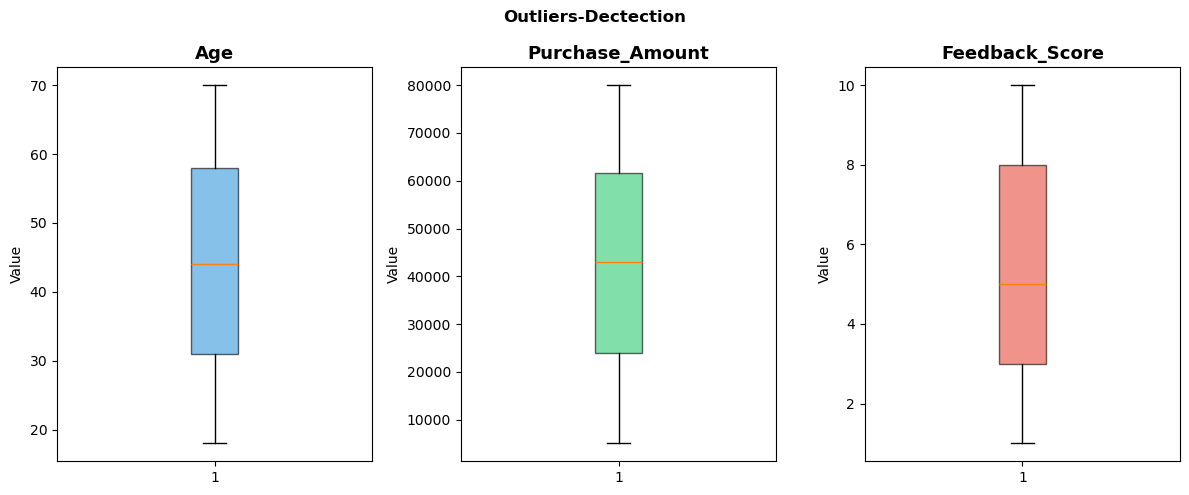

In [34]:
fig,axes=plt.subplots(1,3,figsize=(12,5))

columns=['Age','Purchase_Amount','Feedback_Score']
colors=['#3498db','#2ecc71','#e74c3c']

for ax,col,color in zip(axes,columns,colors):
    ax.boxplot(df[col].dropna(),patch_artist=True,boxprops=dict(facecolor=color,alpha=0.6))
    ax.set_title(f'{col}',fontsize=13,fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('Outliers-Dectection',fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
for col in ['Age', 'Purchase_Amount', 'Feedback_Score']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(col, n)

Age 0
Purchase_Amount 0
Feedback_Score 0


### Created a Boxplot on Age_Group Column by Purchase Amount , avoiding 'UnKnown' values in the boxplot to find the actual contribution of the Groups

C:\Users\Naveed Sultan\AppData\Local\Temp\ipykernel_11920\67995625.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_Group',y='Purchase_Amount',data = Groups,palette='Set2')


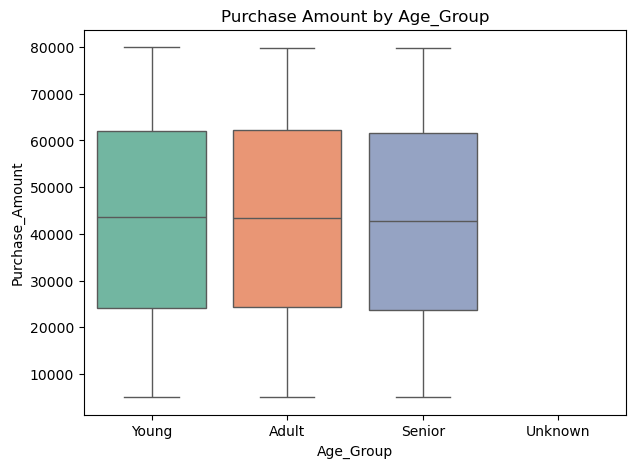

In [36]:
Groups =df[df['Age_Group']!='Unknown']
plt.figure(figsize=(7,5))
sns.boxplot(x='Age_Group',y='Purchase_Amount',data = Groups,palette='Set2')
plt.title('Purchase Amount by Age_Group')
plt.xlabel('Age_Group')
plt.ylabel('Purchase_Amount')
plt.show()

#### Created Bar Chart to comapre the **total purchase amount contributed by each city**.
- Excluded 'Unknown' city values to ensure the analysis reprents only **known customers locations**.

- Identifying the Cities contributing the highest and lowest purchase amount.

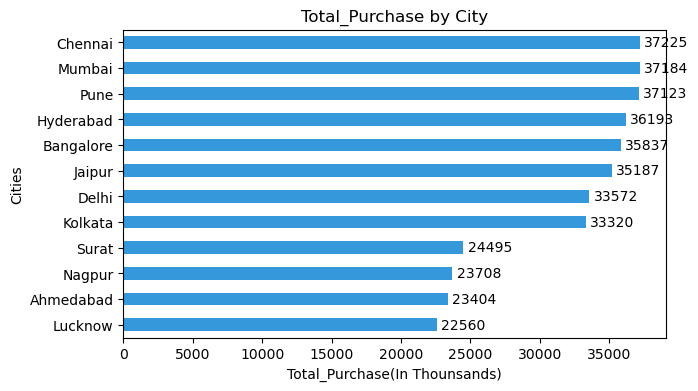

In [37]:
city_data =df[df['City'] != 'Unknown'].groupby('City')['Purchase_Amount'].sum() /1000

city_data = city_data.sort_values()

ax = city_data.plot(kind='barh',color='#3498db',figsize=(7,4))
ax.bar_label(ax.containers[0] ,fmt ='%.0f',padding=3)
ax.set_title('Total_Purchase by City')
ax.set_xlabel('Total_Purchase(In Thounsands)')
ax.set_ylabel('Cities')
plt.show()

### Created a Column Chart to visualize the **number of customers by gender **

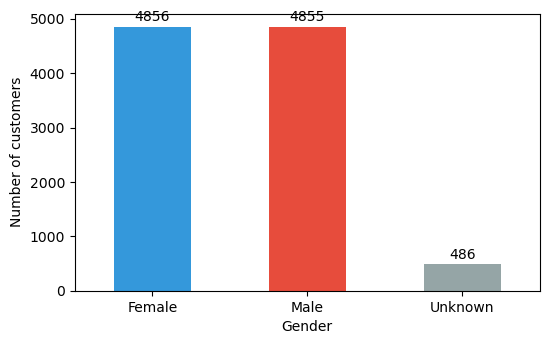

In [38]:
counts = df['Gender'].value_counts()
ax = counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#95a5a6'], rot=0, figsize=(6, 3.6))
ax.bar_label(ax.containers[0], padding=2)          
ax.set_xlabel('Gender')
ax.set_ylabel('Number of customers')
plt.show()

### Created Pie Chart to visualize the **percentage distribution of customers across Age_Groups**
- Including ['Young' , 'Adult' , 'Senior' , 'Unknown'] categories to represent the complete Age_Group distribution.

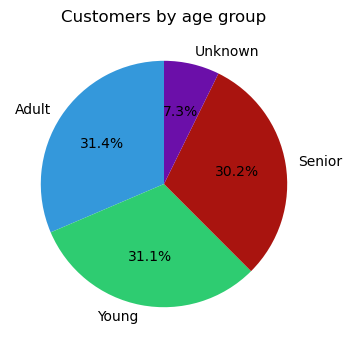

In [39]:
share = df['Age_Group'].value_counts()
plt.figure(figsize=(5, 4))
plt.pie(share, labels=share.index, autopct='%1.1f%%',
        colors=['#3498db', '#2ecc71', "#a9140f",'#6b0fa9'], startangle=90)
plt.title('Customers by age group')
plt.show()

### Purchase amount by last purchase month
- Grouped the purchase amount by the month of each customer's last purchase.
- Marked the highest month on the chart (about 11.9 million in Oct 2023).
- **Note: each row has only one purchase amount and one date, so this shows when customers last bought, not real monthly sales.**

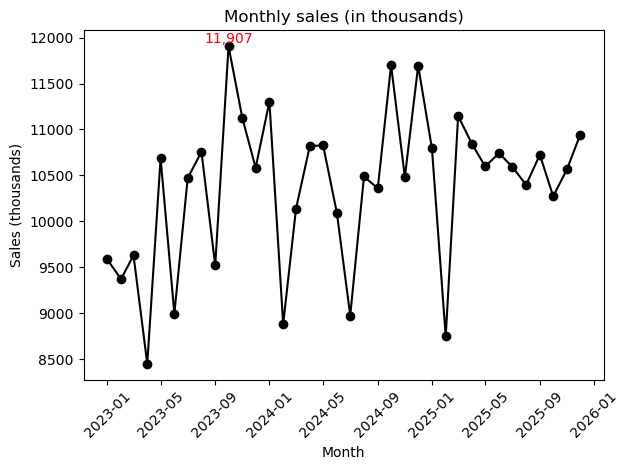

In [40]:
monthly = df.groupby(df['Last_Purchase_Date'].dt.to_period('M'))['Purchase_Amount'].sum() / 1000
monthly.index = monthly.index.to_timestamp()         


plt.plot(monthly.index, monthly.values, marker='o', color='black')
top = monthly.idxmax()                                 
plt.text(top, monthly.max(), f'{monthly.max():,.0f}', ha='center', va='bottom', color='red')
plt.title('Monthly sales (in thousands)')
plt.xlabel('Month')
plt.ylabel('Sales (thousands)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Created a Clustered Chart between City and Age_Group using Crosstab to analyze customer distribution across different cities and Age_groups

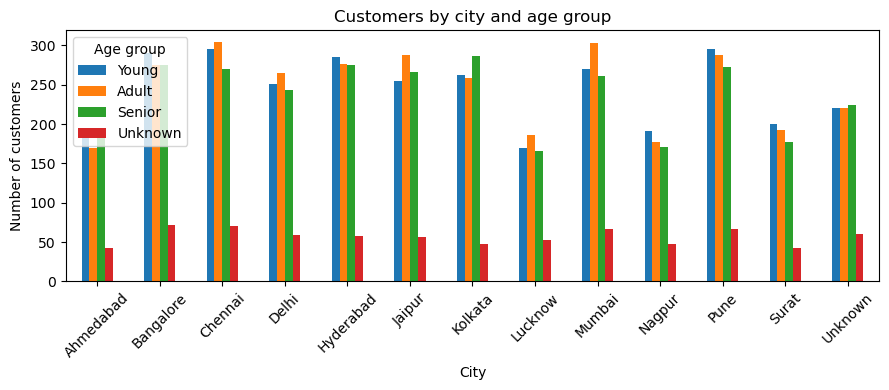

In [41]:
ct = pd.crosstab(df['City'], df['Age_Group'])           
ax = ct.plot(kind='bar', figsize=(9, 4))
ax.set_title('Customers by city and age group')
ax.set_xlabel('City')
ax.set_ylabel('Number of customers')
ax.legend(title='Age group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Created a **scatter plot between Age and Purchase Amount** to analyze the relationship between customer age and their purchase amount.
- Used the visualization to identify whether there is any **positive, negative, or weak relationship** between age and spending.

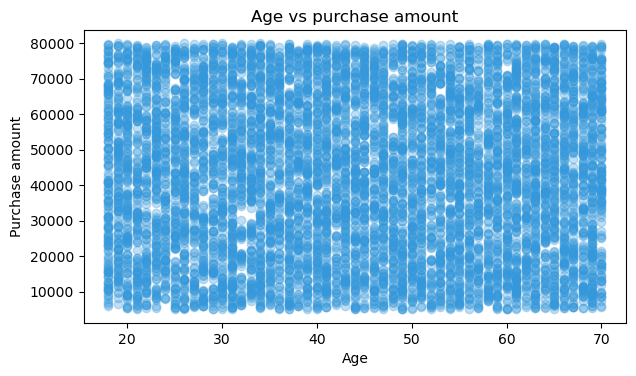

In [42]:
plt.figure(figsize=(7, 3.8))
plt.scatter(df['Age'], df['Purchase_Amount'], alpha=0.3, color='#3498db')
plt.title('Age vs purchase amount')
plt.xlabel('Age')
plt.ylabel('Purchase amount')
plt.show()


### Calculated the **correlation between numerical columns** to identify the strength and direction of relationships between variables.
- Used a **correlation matrix/heatmap** to visually identify positive, negative, and weak correlations.
- This helped understand relationships between numerical variables and identify patterns for further analysis.

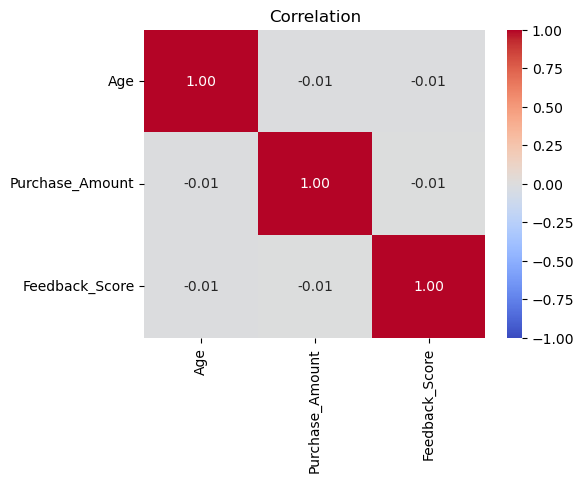

In [43]:
corr = df[['Age', 'Purchase_Amount', 'Feedback_Score']].corr()
plt.figure(figsize=(5.5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation')
plt.show()

## Business KPI's 

### Data Integrity Issue: The Customer ID is not consistently unique. The same Customer ID is associated with multiple customer profiles having different **names, genders, ages, and cities**. Therefore, Customer ID cannot be reliably used as a unique customer identifier. **This may affect customer-level analysis such as unique customer count, repeat/loyal customer identification, customer retention, and churn analysis**.

In [44]:
df.groupby('Customer_ID')['Name'].nunique().sort_values(ascending=False)

Customer_ID
CUST9856     6
CUST2106     6
CUST4438     6
CUST3248     6
CUST9570     6
            ..
CUST2101     1
CUST5697     1
CUST2100     1
CUST5699     1
CUST10000    1
Name: Name, Length: 6390, dtype: int64

In [45]:
df[df['Customer_ID']=='CUST9856']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Date_Issue,Age_Group
1463,CUST9856,Melissa Nelson,Female,58.00,Lucknow,2020-02-24,2023-02-24,"8,756.90",7.00,mnelson@gmail.com,False,Senior
2333,CUST9856,Cynthia Smith,Male,70.00,Pune,2019-11-02,2025-03-16,"14,842.20",7.00,smith25@yahoo.com,False,Senior
4691,CUST9856,Ashley Lopez,Female,48.00,Kolkata,2019-10-07,2025-07-10,"13,935.60",6.00,lopez74@outlook.com,False,Adult
7332,CUST9856,George Rodriguez,Male,20.00,Jaipur,2023-06-28,NaT,"51,477.80",8.00,georgerodriguez@example.com,True,Young
7755,CUST9856,James Adams,Male,66.00,Hyderabad,2022-06-09,2024-03-13,"70,508.20",NaN,adams36@outlook.com,False,Senior
9518,CUST9856,Mark Baker,Male,19.00,Surat,2023-10-08,2024-01-22,"34,191.90",6.00,markbaker@yahoo.com,False,Young


In [46]:
df[df['Customer_ID']=='CUST9570']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Date_Issue,Age_Group
4453,CUST9570,Robert Baker,Female,18.00,Delhi,2018-05-12,2024-07-16,"50,396.70",9.00,robertbaker@hotmail.com,False,Young
4677,CUST9570,Sarah Perez,Female,39.00,Mumbai,2022-06-12,2023-11-20,"28,451.70",7.00,sarahperez@example.com,False,Adult
7090,CUST9570,Susan Hernandez,Male,50.00,Surat,2022-12-30,2024-03-20,"68,483.40",7.00,susanhernandez@hotmail.com,False,Adult
7868,CUST9570,Thomas Lee,Male,29.00,Bangalore,2021-03-20,2025-11-27,"78,669.00",4.00,lee50@hotmail.com,False,Young
8472,CUST9570,Mark Brown,Male,23.00,Kolkata,2019-12-02,2024-02-06,"42,663.90",3.00,markbrown@yahoo.com,False,Young
9407,CUST9570,Rebecca Pierce,Female,52.00,Surat,2023-01-30,2025-12-15,"15,571.60",3.00,rpierce@example.com,False,Adult


In [47]:
Total_Sales = df['Purchase_Amount'].agg(['sum','mean','max','min'])
Total_Sales

sum    408,560,586.60
mean        42,749.88
max         79,997.70
min          5,009.30
Name: Purchase_Amount, dtype: float64

In [48]:
AvgOrderValue=df['Purchase_Amount'].mean().round(2)
print(f'The AvgOrderValue of the business is:{AvgOrderValue}')

The AvgOrderValue of the business is:42749.88


In [49]:
df['Days_To_Last_Purchase']=(df['Last_Purchase_Date'] - df['Signup_Date']).dt.days
print('The Days Between the Last Purchase by the customers',df['Days_To_Last_Purchase'])

The Days Between the Last Purchase by the customers 0       1,878.00
1         987.00
2         691.00
3         314.00
4         720.00
          ...   
10192     318.00
10193   1,260.00
10194   1,644.00
10195     961.00
10196   2,098.00
Name: Days_To_Last_Purchase, Length: 10197, dtype: float64


In [50]:
Avg_Sales = df['Purchase_Amount'].mean().round(2)
print(f'The Average Sales in Business is {Avg_Sales}')

The Average Sales in Business is 42749.88


In [51]:
monthly_Sales = df.groupby(df['Last_Purchase_Date'].dt.to_period('M'))['Purchase_Amount'].sum()

In [52]:
MOM_Growth = monthly_Sales.pct_change() * 100
print('MoM growth in purchase amount (by last purchase month, %):')
print(MOM_Growth.round(2))

MoM growth in purchase amount (by last purchase month, %):
Last_Purchase_Date
2023-01      NaN
2023-02    -2.24
2023-03     2.78
2023-04   -12.28
2023-05    26.50
2023-06   -15.84
2023-07    16.41
2023-08     2.75
2023-09   -11.51
2023-10    25.07
2023-11    -6.55
2023-12    -4.89
2024-01     6.81
2024-02   -21.44
2024-03    14.19
2024-04     6.72
2024-05     0.06
2024-06    -6.80
2024-07   -11.06
2024-08    16.89
2024-09    -1.24
2024-10    12.95
2024-11   -10.42
2024-12    11.57
2025-01    -7.70
2025-02   -18.97
2025-03    27.46
2025-04    -2.73
2025-05    -2.27
2025-06     1.37
2025-07    -1.39
2025-08    -1.85
2025-09     3.15
2025-10    -4.22
2025-11     2.86
2025-12     3.58
Freq: M, Name: Purchase_Amount, dtype: float64


In [53]:
yearly_Sales = df.groupby(df['Last_Purchase_Date'].dt.to_period('Y'))['Purchase_Amount'].sum()

In [54]:
YOY = yearly_Sales.pct_change() * 100
print('YoY growth in purchase amount (by last purchase year, %):')
print(YOY.round(2))

YoY growth in purchase amount (by last purchase year, %):
Last_Purchase_Date
2023    NaN
2024   3.86
2025   0.49
Freq: Y-DEC, Name: Purchase_Amount, dtype: float64


## Custom bands: 8-10 Promoter, 5-7 Passive, 1-4 Detractor, 
 **Not Standard NPS**

In [55]:
df['Feedback'] = np.where(
    df['Feedback_Score'] >= 8,
    'Promoter',
    np.where(
        (df['Feedback_Score'] >= 5) & (df['Feedback_Score'] < 8),
        'Passives',
        np.where(
            (df['Feedback_Score'] >= 1) & (df['Feedback_Score'] < 5),
            'Detractors',
            'No_Feedback'
        )
    )
)

In [56]:
df['Feedback'].value_counts()

Feedback
Detractors     3896
Passives       2939
Promoter       2858
No_Feedback     504
Name: count, dtype: int64

## Conclusion

- The raw file had 203 duplicate rows, 276 impossible dates and messy age, gender and city values. After cleaning, 10,197 usable rows remain.
- Total purchase amount is 408.6 million, with an average of about 42,750 per record.
- Spending per record is almost the same across age groups, genders and cities.
- Surat, Nagpur, Ahmedabad and Lucknow have lower city totals. The reason is fewer records, not lower spending per record.
- 40.2% of feedback scores fall in the Detractor band, but feedback score has no link to purchase amount.
- Yearly purchase amount grew 3.86% in 2024 and 0.49% in 2025. This is based on last purchase date, so it is only a rough signal.
- Customer_ID is not reliable (about 41% of IDs belong to more than one name). Repeat customer, retention and churn analysis cannot be done until this is fixed.

### Next steps
- Ask the data owner why Customer_ID repeats across different people.
- Find out why four cities have fewer records.
- Get order-level data with a date on every purchase to measure real monthly sales.